In [1]:
import json
from tqdm.notebook import tqdm

def load_all_instances(file_path: str):
    """Load all instances from an output.jsonl file."""
    # Count total lines first for accurate progress bar
    with open(file_path, 'r', encoding='utf-8') as f:
        total_lines = sum(1 for line in f if line.strip())

    instances = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in tqdm(f, total=total_lines, desc='Loading instances', unit='instance'):
            line = line.strip()
            if not line:
                continue
            raw = json.loads(line)
            vlog = raw.get('test_result', {}).get('validation_log', [])
            validation_map = {}
            for entry in vlog:
                idx = entry.get('step_index')
                if idx is not None:
                    validation_map[idx] = entry
            instances.append({
                'instance_id': raw.get('instance_id', ''),
                'instance': raw.get('instance', {}),
                'history': raw.get('history', []),
                'git_patch': raw.get('test_result', {}).get('git_patch', ''),
                'validation_log': vlog,
                'validation_map': validation_map,
                'metadata': raw.get('metadata', {}),
                'instruction': raw.get('instruction', ''),
                'metrics': raw.get('metrics', {}),
                'error': raw.get('error'),
            })
    return instances


# Example usage
output_jsonl = '/home/chentianyu/murong/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/SWE-Gym__SWE-Gym-train/CodeActAgent/Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05-run_1/output.jsonl'
instances = load_all_instances(output_jsonl)
print(f'Total instances: {len(instances)}')


Loading instances:   0%|          | 0/2119 [00:00<?, ?instance/s]

Total instances: 2119


In [2]:
instances[0].keys()

dict_keys(['instance_id', 'instance', 'history', 'git_patch', 'validation_log', 'validation_map', 'metadata', 'instruction', 'metrics', 'error'])

In [9]:
instances[0]['instance'].keys()

dict_keys(['instance_id', 'hints_text', 'patch', 'test_patch', 'created_at', 'problem_statement', 'repo', 'base_commit', 'version', 'PASS_TO_PASS', 'FAIL_TO_PASS'])

In [3]:

def format_history_for_llm(history, max_message_len=1000):
    """Format an instance's history into a human/LLM-readable string.

    Actions (→) are things the agent/user actively does.
    Observations (←) are responses/results from the environment.
    """
    lines = []
    for i, entry in enumerate(history):
        source = entry.get('source', '?')
        action = entry.get('action', '')
        observation = entry.get('observation', '')
        message = entry.get('message', '')
        args = entry.get('args', {}) or {}

        # Role label
        if source == 'agent':
            role = 'AGENT'
        elif source == 'user':
            role = 'USER'
        elif source == 'environment':
            role = 'ENV'
        else:
            role = source.upper()

        # Distinguish action vs observation with arrow and label
        if action:
            direction = '→'
            kind = f'action:{action}'
        elif observation:
            direction = '←'
            kind = f'obs:{observation}'
        else:
            direction = ' '
            kind = 'message'

        # Pick the most informative content per action/observation type
        if action == 'message':
            content = message
        elif action == 'think':
            content = args.get('thought', message)
        elif action == 'run':
            content = args.get('command', message)
        elif action in ('read', 'write', 'edit'):
            # args typically has 'command', 'path', 'old_str', 'new_str'
            cmd = args.get('command', '')
            path = args.get('path', '')
            old_str = args.get('old_str', '')
            new_str = args.get('new_str', '')
            if cmd == 'str_replace' and (old_str or new_str):
                content = f'[{cmd}] {path}\n--- old ---\n{old_str}\n+++ new +++\n{new_str}'
            elif cmd in ('view', 'create', 'insert', 'undo_edit'):
                body = args.get('file_text', args.get('new_str', message))
                content = f'[{cmd}] {path}' + (f'\n{body}' if body else '')
            else:
                content = f'[{cmd}] {path}' if (cmd or path) else message
        elif observation:
            content = entry.get('content', '') or message
        else:
            content = entry.get('content', '') or message

        # Truncate long content
        if content and len(content) > max_message_len and (role == 'ENV' or i ==0):
            content = content[:max_message_len] + f'... [truncated, total {len(content)} chars]'

        lines.append(f'[{i:3d}] {role:<5} {direction} {kind}: {content}')

    return '\n\n'.join(lines)


print(format_history_for_llm(instances[0]['history']))


[  0] AGENT → action:system: You are OpenHands agent, a helpful AI assistant that can interact with a computer to solve tasks.

<ROLE>
Your primary role is to assist users by executing commands, modifying code, and solving technical problems effectively. You should be thorough, methodical, and prioritize quality over speed.
* If the user asks a question, like "why is X happening", don't try to fix the problem. Just give an answer to the question.
</ROLE>

<EFFICIENCY>
* Each action you take is somewhat expensive. Wherever possible, combine multiple actions into a single action, e.g. combine multiple bash commands into one, using sed and grep to edit/view multiple files at once.
* When exploring the codebase, use efficient tools like find, grep, and git commands with appropriate filters to minimize unnecessary operations.
</EFFICIENCY>

<FILE_SYSTEM_GUIDELINES>
* When a user provides a file path, do NOT assume it's relative to the current working directory. First explore the file system

In [4]:

# ── Shared context builder ────────────────────────────────────────────────────

def _extract_context(inst: dict, max_traj_len: int = 200000) -> dict:
    """Extract all reusable context fields from an instance."""
    d = inst['instance']
    trajectory = format_history_for_llm(inst['history'], max_message_len=800)
    if len(trajectory) > max_traj_len:
        trajectory = trajectory[:max_traj_len] + f'\n\n... [trajectory truncated, total {len(trajectory)} chars]'
    return dict(
        problem=d.get('problem_statement', '').strip(),
        golden_patch=d.get('patch', '').strip(),
        test_patch=d.get('test_patch', '').strip(),
        generated_patch=inst.get('git_patch', '').strip() or '(no patch generated)',
        trajectory=trajectory,
    )


# ── Dimension-specific prompt builders ───────────────────────────────────────

def build_fix_quality_prompt(ctx: dict) -> tuple[str, str]:
    """Does the generated patch correctly fix the issue?"""
    system = """\
You are an expert software engineer. Evaluate whether the agent's generated patch
correctly fixes the reported GitHub issue, compared to the ground-truth patch.

The fix does NOT need to be identical — semantic equivalence is sufficient.
Focus only on correctness and completeness of the fix, not on style or tests.

Respond with a JSON object exactly matching this schema (no extra text):
{
  "score": <int 0-4>,
  "reasoning": "<concise explanation>"
}

Scoring rubric:
  4 = Fully correct fix, matches intent of ground-truth patch
  3 = Mostly correct, minor gaps or slightly different approach
  2 = Partially correct, addresses some but not all aspects of the issue
  1 = Barely correct, largely misses the problem
  0 = Completely wrong or no patch generated"""

    user = f"""\
## Problem Statement
{ctx['problem']}

---
## Ground-Truth Patch (correct fix)
```diff
{ctx['golden_patch']}
```

---
## Agent-Generated Patch
```diff
{ctx['generated_patch']}
```
"""
    return system, user


def build_test_intent_prompt(ctx: dict) -> tuple[str, str]:
    """Does the fix address what the ground-truth tests verify?"""
    system = """\
You are an expert software engineer. Given a ground-truth test patch and an
agent-generated code patch, evaluate whether the agent's fix would satisfy the
intent of the ground-truth tests — i.e., would the ground-truth tests pass if
applied on top of the agent's patch?

Focus only on test coverage intent, not on patch style or unrelated behavior.

Respond with a JSON object exactly matching this schema (no extra text):
{
  "score": <int 0-4>,
  "reasoning": "<concise explanation>"
}

Scoring rubric:
  4 = Agent's fix fully satisfies what the tests verify
  3 = Mostly satisfies, minor gaps
  2 = Partially satisfies, some tests would likely fail
  1 = Barely satisfies, most tests would fail
  0 = Completely fails or no patch generated"""

    user = f"""\
## Problem Statement
{ctx['problem']}

---
## Ground-Truth Test Patch (what correctness looks like)
```diff
{ctx['test_patch']}
```

---
## Agent-Generated Patch
```diff
{ctx['generated_patch']}
```
"""
    return system, user


def build_trajectory_coherence_prompt(ctx: dict) -> tuple[str, str]:
    """Is the agent's reasoning and decision-making sound throughout?"""
    system = """\
You are an expert software engineer reviewing a code agent's execution trajectory
on a GitHub issue resolution task.

Evaluate the quality of the agent's reasoning and decision-making process.
Do NOT evaluate the final patch quality — focus solely on the trajectory itself.

Criteria to assess:
- Correct problem diagnosis: did the agent understand the issue?
- Logical planning: did it form a sensible plan before acting?
- Efficient tool use: no unnecessary retries, redundant searches, or wasted steps
- Consistent reasoning: no contradictions or abrupt direction changes
- Sound decisions: each step follows logically from the previous

Respond with a JSON object exactly matching this schema (no extra text):
{
  "score": <int 0-4>,
  "reasoning": "<concise explanation, highlight specific good/bad decisions>"
}

Scoring rubric:
  4 = Excellent reasoning throughout, efficient and consistent
  3 = Good overall, minor inefficiencies or one poor decision
  2 = Partial, some correct steps but notable confusion or wasted effort
  1 = Poor, mostly confused or thrashing with little forward progress
  0 = Completely incoherent or no trajectory"""

    user = f"""\
## Problem Statement
{ctx['problem']}

---
## Agent Trajectory
{ctx['trajectory']}
"""
    return system, user


# ── Registry: name → prompt builder ──────────────────────────────────────────
DIMENSION_BUILDERS = {
    "fix_quality":          build_fix_quality_prompt,
    "test_intent_coverage": build_test_intent_prompt,
    "trajectory_coherence": build_trajectory_coherence_prompt,
}


def print_dimension_prompt(inst: dict, dimension: str, **ctx_kwargs) -> None:
    """Print the prompt for a specific evaluation dimension without calling the LLM.

    Args:
        inst:      Instance dict.
        dimension: One of 'fix_quality', 'test_intent_coverage', 'trajectory_coherence'.
    """
    assert dimension in DIMENSION_BUILDERS, f"Unknown dimension: {dimension!r}. Choose from {list(DIMENSION_BUILDERS)}"
    ctx = _extract_context(inst, **ctx_kwargs)
    system, user = DIMENSION_BUILDERS[dimension](ctx)
    sep = "─" * 80
    print(f"{sep}\n[SYSTEM — {dimension}]\n{sep}")
    print(system)
    print(f"\n{sep}\n[USER — {dimension}]\n{sep}")
    print(user)


In [5]:

import os
import re
import json
from openai import OpenAI


def call_llm_judge(
    system_prompt: str,
    user_prompt: str,
    model: str = "Qwen/Qwen3-Coder-30B-A3B-Instruct",
    api_key: str = "not-needed",
    base_url: str = "http://localhost:8000/v1",
    extra_body: dict | None = None,
) -> dict:
    """Call an OpenAI-compatible LLM and return a parsed JSON dict."""
    client = OpenAI(api_key=api_key, base_url=base_url)
    kwargs = dict(
        model=model,
        temperature=0.0,
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": user_prompt},
        ],
        response_format={"type": "json_object"},
    )
    if extra_body:
        kwargs["extra_body"] = extra_body

    response = client.chat.completions.create(**kwargs)
    raw = response.choices[0].message.content

    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        pass
    # Fallback: strip markdown fences and extract first {...} block
    match = re.search(r'\{.*\}', raw, re.DOTALL)
    if match:
        return json.loads(match.group())
    raise ValueError(f"Could not parse JSON from LLM response:\n{raw}")


def evaluate_instance(
    inst: dict,
    dimensions: list[str] | None = None,
    print_prompt: bool = False,
    **llm_kwargs,
) -> dict:
    """Run per-dimension LLM-as-judge evaluation on a single instance.

    Each dimension is evaluated with a separate, focused LLM call.

    Args:
        inst:        Instance dict from load_all_instances.
        dimensions:  Subset of dimensions to evaluate. Defaults to all three.
                     Choices: 'fix_quality', 'test_intent_coverage', 'trajectory_coherence'
        print_prompt: If True, print each dimension's prompt before calling the LLM.
        **llm_kwargs: Forwarded to call_llm_judge.

    Returns:
        Dict with per-dimension results and an averaged overall_score.
    """
    if dimensions is None:
        dimensions = list(DIMENSION_BUILDERS.keys())

    print(f"Evaluating [{inst['instance_id']}]  dimensions: {dimensions}")
    ctx = _extract_context(inst)
    results = {"instance_id": inst["instance_id"]}
    scores = []

    for dim in dimensions:
        assert dim in DIMENSION_BUILDERS, f"Unknown dimension: {dim!r}"
        system, user = DIMENSION_BUILDERS[dim](ctx)

        if print_prompt:
            sep = "─" * 80
            print(f"\n{sep}\n[PROMPT — {dim}]\n{sep}")
            print(f"[SYSTEM]\n{system}\n\n[USER]\n{user}")

        print(f"  · {dim} ...", end=" ", flush=True)
        dim_result = call_llm_judge(system, user, **llm_kwargs)
        results[dim] = dim_result
        scores.append(dim_result.get("score", 0))
        print(f"[{dim_result.get('score', '?')}/4]")

    results["overall_score"] = round(sum(scores) / len(scores), 2) if scores else 0
    return results


In [6]:

# ── LLM config — locally served vLLM endpoint ────────────────────────────────
LLM_CONFIG = dict(
    model="Qwen/Qwen3-Coder-480B-A35B-Instruct",
    api_key="not-needed",
    base_url="http://localhost:8000/v1",
    extra_body={"chat_template_kwargs": {"enable_thinking": False}},
)

inst = next(i for i in instances if i["instance_id"] == "getmoto__moto-5812")

# ── Inspect a single dimension's prompt (no LLM call) ────────────────────────
# print_dimension_prompt(inst, "fix_quality")
# print_dimension_prompt(inst, "test_intent_coverage")
# print_dimension_prompt(inst, "trajectory_coherence")

# ── Evaluate all dimensions (separate LLM call per dimension) ────────────────
result = evaluate_instance(inst, print_prompt=False, **LLM_CONFIG)

# ── Evaluate a subset of dimensions ──────────────────────────────────────────
# result = evaluate_instance(inst, dimensions=["fix_quality", "test_intent_coverage"], **LLM_CONFIG)

# ── Pretty-print results ──────────────────────────────────────────────────────
print()
for dim in ("fix_quality", "test_intent_coverage", "trajectory_coherence"):
    if dim not in result:
        continue
    score = result[dim]["score"]
    reason = result[dim]["reasoning"]
    print(f"{dim:28s}  [{score}/4]  {reason}")

print(f"\nOverall score (avg): {result['overall_score']}/4")


Evaluating [getmoto__moto-5812]  dimensions: ['fix_quality', 'test_intent_coverage', 'trajectory_coherence']
  · fix_quality ... [0/4]
  · test_intent_coverage ... [4/4]
  · trajectory_coherence ... [4/4]

fix_quality                   [0/4]  The agent's patch does not address the core issue at all. Instead of fixing the IoT Data publish functionality by modifying the URL routing and response handling (as shown in the ground-truth patch), the agent made changes to the botocore stubber and created numerous test files. The root cause was in how IoT Data publish requests were being routed and processed, specifically in the responses.py and urls.py files. The agent's changes to botocore_stubber.py actually modify a different part of the system entirely and would likely break other functionality. The fix is completely incorrect and does not solve the reported problem where subsequent publish calls lose their topic information.
test_intent_coverage          [4/4]  The agent's fix directly ad

In [8]:

# Inspect any single dimension's prompt
print_dimension_prompt(inst, "fix_quality")
# print_dimension_prompt(inst, "test_intent_coverage")
# print_dimension_prompt(inst, "trajectory_coherence")


────────────────────────────────────────────────────────────────────────────────
[SYSTEM — fix_quality]
────────────────────────────────────────────────────────────────────────────────
You are an expert software engineer. Evaluate whether the agent's generated patch
correctly fixes the reported GitHub issue, compared to the ground-truth patch.

The fix does NOT need to be identical — semantic equivalence is sufficient.
Focus only on correctness and completeness of the fix, not on style or tests.

Respond with a JSON object exactly matching this schema (no extra text):
{
  "score": <int 0-4>,
  "reasoning": "<concise explanation>"
}

Scoring rubric:
  4 = Fully correct fix, matches intent of ground-truth patch
  3 = Mostly correct, minor gaps or slightly different approach
  2 = Partially correct, addresses some but not all aspects of the issue
  1 = Barely correct, largely misses the problem
  0 = Completely wrong or no patch generated

─────────────────────────────────────────────────

In [ ]:

import pathlib
import threading
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.notebook import tqdm


def _evaluate_one(inst: dict, dims: list[str], llm_config: dict) -> dict:
    """Evaluate a single instance across all requested dimensions. Thread-safe."""
    ctx = _extract_context(inst)
    scores = []
    judgment = {"instance_id": inst["instance_id"]}
    for dim in dims:
        system, user = DIMENSION_BUILDERS[dim](ctx)
        dim_result = call_llm_judge(system, user, **llm_config)
        judgment[dim] = dim_result
        scores.append(dim_result.get("score", 0))
    judgment["overall_score"] = round(sum(scores) / len(scores), 2) if scores else 0
    return judgment


def run_batch_evaluation(
    instances: list[dict],
    llm_config: dict,
    max_instances: int | None = 10,
    output_path: str = "judge_results.jsonl",
    dimensions: list[str] | None = None,
    skip_existing: bool = True,
    max_workers: int = 4,
) -> list[dict]:
    """Evaluate up to max_instances instances in parallel and save results to JSONL.

    Each instance is evaluated with one LLM call per dimension. Workers run
    concurrently via a thread pool (safe for I/O-bound HTTP calls to vLLM).
    Results are written atomically as each future completes; safe to re-run
    with skip_existing=True to resume after interruption.

    Args:
        instances:      Full list of instances from load_all_instances.
        llm_config:     LLM kwargs forwarded to call_llm_judge.
        max_instances:  Cap on how many new instances to evaluate. None = all.
        output_path:    Path to the JSONL file where results are appended.
        dimensions:     Dimension names to evaluate. None = all three.
        skip_existing:  If True, skip instance_ids already in the output file.
        max_workers:    Number of parallel threads (tune to vLLM concurrency).
    """
    _dims = dimensions if dimensions is not None else list(DIMENSION_BUILDERS.keys())
    out = pathlib.Path(output_path)
    write_lock = threading.Lock()

    # Load already-completed instance_ids so we can resume
    completed_ids: set[str] = set()
    if skip_existing and out.exists():
        with out.open() as f:
            for line in f:
                line = line.strip()
                if line:
                    try:
                        completed_ids.add(json.loads(line)["instance_id"])
                    except Exception:
                        pass
        if completed_ids:
            print(f"Skipping {len(completed_ids)} already-evaluated instance(s).")

    todo = [i for i in instances if i["instance_id"] not in completed_ids]
    if max_instances is not None:
        todo = todo[:max_instances]

    print(f"Will evaluate {len(todo)} instance(s) with {max_workers} workers → {out}")
    new_results = []

    with out.open("a") as f, ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {
            executor.submit(_evaluate_one, inst, _dims, llm_config): inst
            for inst in todo
        }

        with tqdm(total=len(futures), desc="Evaluating", unit="inst") as pbar:
            for future in as_completed(futures):
                inst = futures[future]
                iid = inst["instance_id"]
                try:
                    judgment = future.result()
                    scores_str = "  ".join(
                        f"{d}={judgment[d]['score']}/4"
                        for d in _dims if d in judgment
                    )
                    pbar.write(f"✓ {iid}  {scores_str}  overall={judgment['overall_score']}")
                except Exception as e:
                    judgment = {"instance_id": iid, "error": str(e)}
                    pbar.write(f"✗ {iid}  ERROR: {e}")

                with write_lock:
                    f.write(json.dumps(judgment) + "\n")
                    f.flush()

                new_results.append(judgment)
                pbar.update(1)

    print(f"\nDone. {len(new_results)} new result(s) saved to {out}")
    return new_results


In [ ]:

# ── Batch evaluation config ───────────────────────────────────────────────────
BATCH_OUTPUT  = "judge_results.jsonl"
MAX_INSTANCES = 500    # set to None to evaluate all
MAX_WORKERS   = 16      # parallel threads — tune to your vLLM server concurrency

batch_results = run_batch_evaluation(
    instances=instances,
    llm_config=LLM_CONFIG,
    max_instances=MAX_INSTANCES,
    output_path=BATCH_OUTPUT,
    dimensions=None,       # None = all three dimensions
    skip_existing=True,    # resume from where you left off
    max_workers=MAX_WORKERS,
)

# ── Summary stats ─────────────────────────────────────────────────────────────
valid = [r for r in batch_results if "error" not in r]
errors = [r for r in batch_results if "error" in r]
print(f"\n{len(valid)} succeeded, {len(errors)} failed")
if valid:
    for dim in ("fix_quality", "test_intent_coverage", "trajectory_coherence"):
        scores = [r[dim]["score"] for r in valid if dim in r]
        if scores:
            print(f"{dim:28s}  avg={sum(scores)/len(scores):.2f}  n={len(scores)}")
    overall = [r["overall_score"] for r in valid]
    print(f"{'overall_score':28s}  avg={sum(overall)/len(overall):.2f}")


Will evaluate 100 instance(s) → judge_results.jsonl

[1/100] Evaluating: getmoto__moto-4950
  · fix_quality ... [4/4]
  · test_intent_coverage ... [4/4]
  · trajectory_coherence ... [4/4]

[2/100] Evaluating: getmoto__moto-5876
  · fix_quality ... [3/4]
  · test_intent_coverage ... [3/4]
  · trajectory_coherence ... [4/4]

[3/100] Evaluating: getmoto__moto-5212
  · fix_quality ... [3/4]
  · test_intent_coverage ... [4/4]
  · trajectory_coherence ... [4/4]

[4/100] Evaluating: getmoto__moto-5386
  · fix_quality ... [3/4]
  · test_intent_coverage ... [4/4]
  · trajectory_coherence ... [4/4]

[5/100] Evaluating: getmoto__moto-6920
  · fix_quality ... [4/4]
  · test_intent_coverage ... [4/4]
  · trajectory_coherence ... [4/4]

[6/100] Evaluating: getmoto__moto-7365
  · fix_quality ... [3/4]
  · test_intent_coverage ... [4/4]
  · trajectory_coherence ... [4/4]

[7/100] Evaluating: getmoto__moto-5085
  · fix_quality ... [3/4]
  · test_intent_coverage ... [4/4]
  · trajectory_coherence ... [4

In [12]:

# ── Load judge results and swebench eval results, then join by instance_id ────
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from collections import defaultdict

JUDGE_RESULTS_PATH = "/home/chentianyu/murong/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_analysis/judge_results.jsonl"
SWEBENCH_EVAL_PATH = (
    "/home/chentianyu/murong/code/OpenHands_SWE-Bench-Optimized/evaluation/evaluation_outputs/outputs/"
    "SWE-Gym__SWE-Gym-train/CodeActAgent/"
    "Qwen3-Coder-480B-A35B-Instruct_maxiter_100_N_v0.61.0-no-hint-train-qwen3_coder_480b_a35b_instruct-t05-run_1/"
    "output.swebench_eval.jsonl"
)

def load_jsonl(path, silent_errors=False):
    """Load a JSONL file, skipping lines that fail to parse."""
    records = []
    errors = 0
    with open(path) as f:
        for lineno, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError as e:
                errors += 1
                if not silent_errors:
                    print(f"  [warn] line {lineno}: {e}")
    if errors:
        print(f"  Skipped {errors} malformed line(s) in {os.path.basename(path)}")
    return records

print("Loading judge results…")
judge_records = load_jsonl(JUDGE_RESULTS_PATH)
print(f"  {len(judge_records)} judge records loaded")

print("Loading swebench eval results…")
eval_records = load_jsonl(SWEBENCH_EVAL_PATH, silent_errors=True)
print(f"  {len(eval_records)} eval records loaded")

# Build lookup: instance_id -> resolved bool
eval_map = {
    r["instance_id"]: r.get("test_result", {}).get("report", {}).get("resolved", None)
    for r in eval_records
    if "instance_id" in r
}
print(f"  {len(eval_map)} unique instance_ids in eval map")

# ── Enrich judge_results.jsonl with resolved field ───────────────────────────
enriched = []
updated_count = 0
for r in judge_records:
    iid = r.get("instance_id")
    resolved = eval_map.get(iid)  # None if not in eval
    new_r = dict(r)
    if resolved is not None and "resolved" not in r:
        new_r["resolved"] = resolved
        updated_count += 1
    elif "resolved" not in r:
        new_r["resolved"] = None
    enriched.append(new_r)

# Write back the enriched records in-place
with open(JUDGE_RESULTS_PATH, "w") as f:
    for r in enriched:
        f.write(json.dumps(r) + "\n")
print(f"\nWrote {len(enriched)} records back to judge_results.jsonl ({updated_count} newly enriched with resolved)")

# ── Build dataframe from the (judge-results) subset ──────────────────────────
rows = []
for r in enriched:
    iid = r.get("instance_id")
    if iid is None:
        continue
    resolved = r.get("resolved")
    row = {"instance_id": iid, "resolved": resolved}
    for dim in ("fix_quality", "test_intent_coverage", "trajectory_coherence"):
        row[dim] = r.get(dim, {}).get("score") if isinstance(r.get(dim), dict) else None
    row["overall_score"] = r.get("overall_score")
    rows.append(row)

df = pd.DataFrame(rows)
df["resolved"] = df["resolved"].astype("boolean")

has_eval = df["resolved"].notna()
print(f"\nTotal judge results:          {len(df)}")
print(f"With resolved label:          {has_eval.sum()}")
print(f"Without resolved label:       {(~has_eval).sum()}")
print()
print(df[has_eval].head(5))


Loading judge results…
  700 judge records loaded
Loading swebench eval results…


  Skipped 1 malformed line(s) in output.swebench_eval.jsonl
  2119 eval records loaded
  2119 unique instance_ids in eval map

Wrote 700 records back to judge_results.jsonl (700 newly enriched with resolved)

Total judge results:          700
With resolved label:          700
Without resolved label:       0

          instance_id  resolved  fix_quality  test_intent_coverage  \
0  getmoto__moto-4950      True          4.0                   4.0   
1  getmoto__moto-5876     False          3.0                   3.0   
2  getmoto__moto-5212     False          3.0                   4.0   
3  getmoto__moto-5386      True          3.0                   4.0   
4  getmoto__moto-6920      True          4.0                   4.0   

   trajectory_coherence  overall_score  
0                   4.0           4.00  
1                   4.0           3.33  
2                   4.0           3.67  
3                   4.0           3.67  
4                   4.0           4.00  


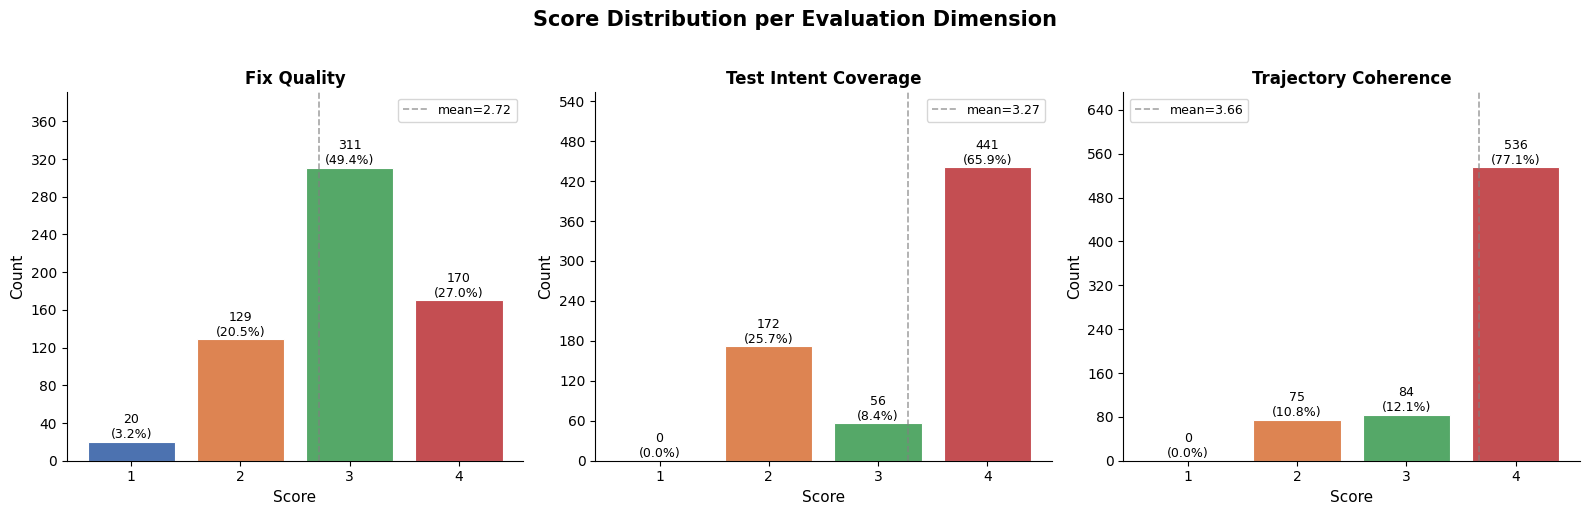

Saved: score_distribution.png


In [13]:

# ── Score distribution per dimension ─────────────────────────────────────────
DIMS = ["fix_quality", "test_intent_coverage", "trajectory_coherence"]
DIM_LABELS = {
    "fix_quality": "Fix Quality",
    "test_intent_coverage": "Test Intent Coverage",
    "trajectory_coherence": "Trajectory Coherence",
}
SCORE_VALUES = [1, 2, 3, 4]
COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Score Distribution per Evaluation Dimension", fontsize=15, fontweight="bold", y=1.02)

for ax, dim in zip(axes, DIMS):
    counts = df[dim].value_counts().reindex(SCORE_VALUES, fill_value=0)
    bars = ax.bar(counts.index.astype(str), counts.values, color=COLORS, edgecolor="white", linewidth=0.8)
    
    total = counts.sum()
    for bar, cnt in zip(bars, counts.values):
        pct = cnt / total * 100 if total > 0 else 0
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{cnt}\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=9
        )
    
    ax.set_title(DIM_LABELS[dim], fontsize=12, fontweight="bold")
    ax.set_xlabel("Score", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.set_ylim(0, counts.max() * 1.25 + 2)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    # Annotate mean
    mean_score = df[dim].mean()
    ax.axvline(x=mean_score - 1, color="gray", linestyle="--", linewidth=1.2, alpha=0.7, label=f"mean={mean_score:.2f}")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: score_distribution.png")


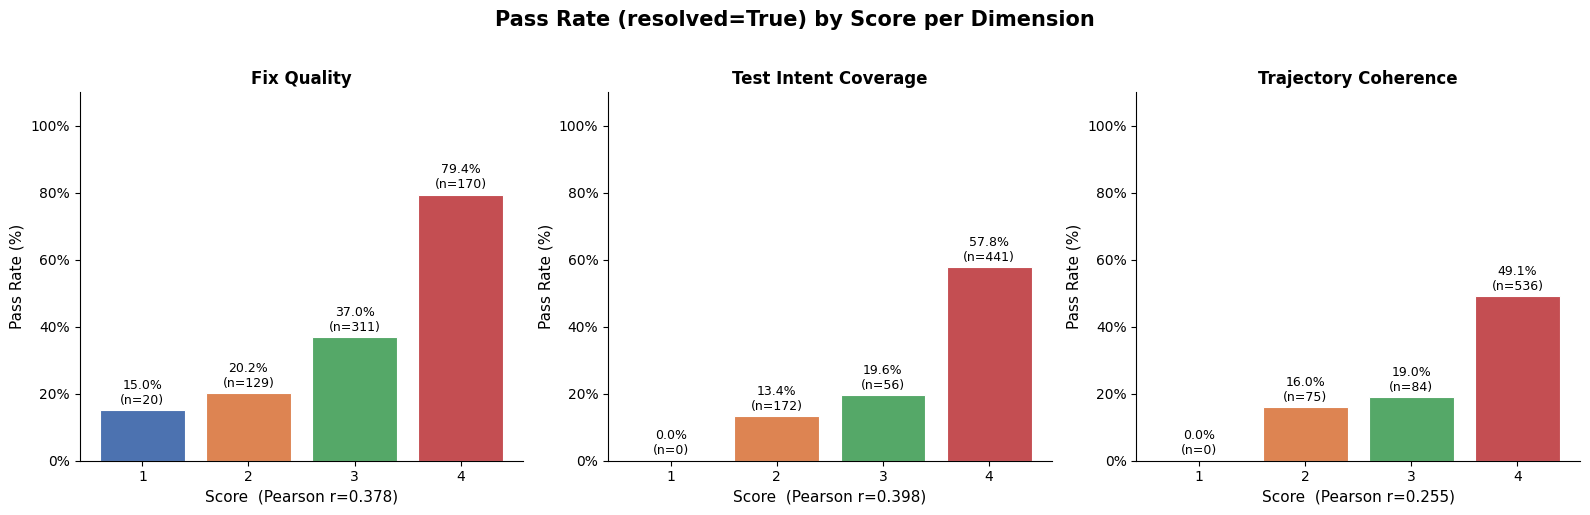

Saved: pass_rate_by_score.png


In [15]:

# ── Pass rate by score for each dimension ─────────────────────────────────────
# Only use instances that appear in both files
df_eval = df[df["resolved"].notna()].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Pass Rate (resolved=True) by Score per Dimension", fontsize=15, fontweight="bold", y=1.02)

for ax, dim in zip(axes, DIMS):
    group = df_eval.groupby(dim)["resolved"].agg(["sum", "count"]).reindex(SCORE_VALUES, fill_value=0)
    pass_rate = (group["sum"] / group["count"].replace(0, np.nan) * 100).fillna(0)
    n_per_score = group["count"]
    
    bars = ax.bar(pass_rate.index.astype(str), pass_rate.values,
                  color=COLORS, edgecolor="white", linewidth=0.8)
    
    for bar, rate, n in zip(bars, pass_rate.values, n_per_score.values):
        label = f"{rate:.1f}%\n(n={int(n)})"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            label, ha="center", va="bottom", fontsize=9
        )
    
    ax.set_title(DIM_LABELS[dim], fontsize=12, fontweight="bold")
    ax.set_xlabel("Score", fontsize=11)
    ax.set_ylabel("Pass Rate (%)", fontsize=11)
    ax.set_ylim(0, 110)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    # Pearson correlation between score and resolved
    valid = df_eval[[dim, "resolved"]].dropna()
    if len(valid) > 1:
        corr = valid[dim].corr(valid["resolved"].astype(float))
        ax.set_xlabel(f"Score  (Pearson r={corr:.3f})", fontsize=11)

plt.tight_layout()
plt.savefig("pass_rate_by_score.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: pass_rate_by_score.png")


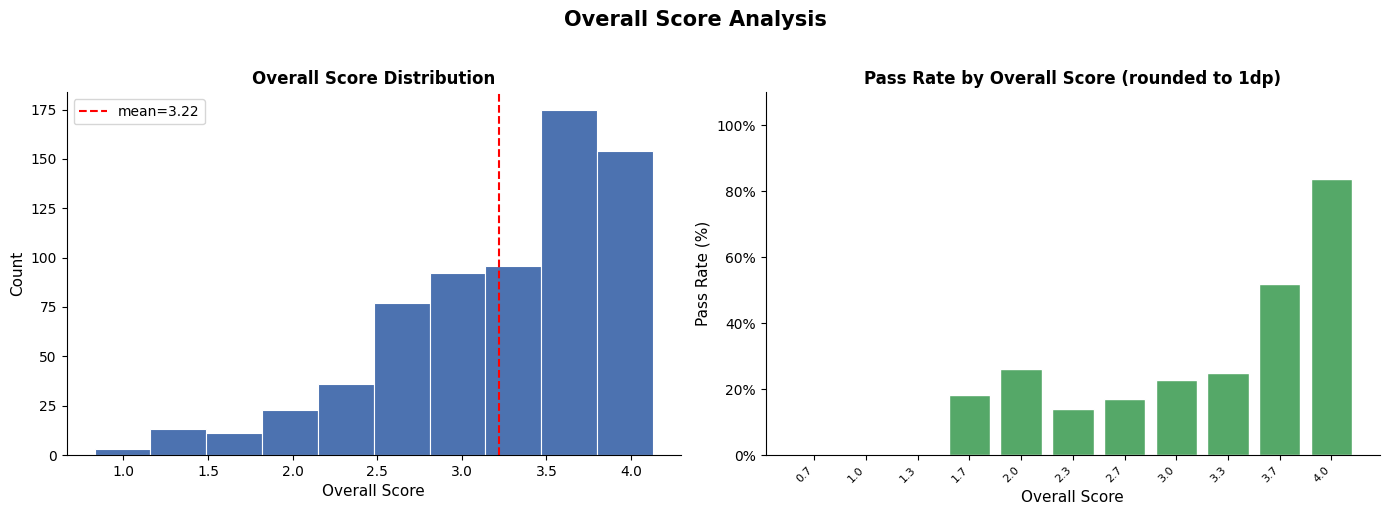

Saved: overall_score_analysis.png


In [16]:

# ── Overall score distribution + pass rate heat-map style ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Overall Score Analysis", fontsize=15, fontweight="bold", y=1.02)

# Left: distribution of overall_score (rounded to nearest 0.33 step: 1/1.33/1.67/…/4)
ax = axes[0]
bins = np.arange(0.83, 4.3, 0.33)   # bin edges centred on 1, 1.33, 1.67, 2, 2.33, ...
ax.hist(df["overall_score"].dropna(), bins=bins, color="#4C72B0", edgecolor="white", linewidth=0.8)
ax.set_title("Overall Score Distribution", fontsize=12, fontweight="bold")
ax.set_xlabel("Overall Score", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.axvline(df["overall_score"].mean(), color="red", linestyle="--", linewidth=1.5,
           label=f"mean={df['overall_score'].mean():.2f}")
ax.legend(fontsize=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Right: pass rate bucketed by overall_score (rounded to 1 decimal)
ax2 = axes[1]
df_eval2 = df[df["resolved"].notna()].copy()
df_eval2["overall_bucket"] = df_eval2["overall_score"].round(1)
grp2 = df_eval2.groupby("overall_bucket")["resolved"].agg(["sum", "count"])
grp2["pass_rate"] = grp2["sum"] / grp2["count"] * 100

ax2.bar(grp2.index.astype(str), grp2["pass_rate"], color="#55A868", edgecolor="white")
ax2.set_title("Pass Rate by Overall Score (rounded to 1dp)", fontsize=12, fontweight="bold")
ax2.set_xlabel("Overall Score", fontsize=11)
ax2.set_ylabel("Pass Rate (%)", fontsize=11)
ax2.set_ylim(0, 110)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
# Rotate x labels to avoid overlap
plt.setp(ax2.get_xticklabels(), rotation=45, ha="right", fontsize=8)

plt.tight_layout()
plt.savefig("overall_score_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: overall_score_analysis.png")


In [17]:

# ── Summary table: pass rate & score stats per dimension ─────────────────────
from IPython.display import display

ALL_DIMS = DIMS + ["overall_score"]
rows_sum = []
df_eval3 = df[df["resolved"].notna()].copy()
total_resolved = int(df_eval3["resolved"].sum())
total_eval = len(df_eval3)

for dim in ALL_DIMS:
    col = df[dim].dropna()
    col_eval = df_eval3[dim].dropna()

    row = {
        "Dimension": DIM_LABELS.get(dim, dim.replace("_", " ").title()),
        "N (judge)": len(col),
        "Mean": round(col.mean(), 3),
        "Std": round(col.std(), 3),
        "Min": col.min(),
        "Max": col.max(),
        "N (w/ eval)": len(df_eval3[df_eval3[dim].notna()]),
    }
    # Pass rate per score bucket
    valid_eval = df_eval3[[dim, "resolved"]].dropna()
    for score_val in SCORE_VALUES:
        subset = valid_eval[valid_eval[dim] == score_val]
        if len(subset) > 0:
            row[f"PR@{score_val}"] = f"{subset['resolved'].mean()*100:.1f}% ({len(subset)})"
        else:
            row[f"PR@{score_val}"] = "—"
    
    if dim == "overall_score":
        # skip per-score PR for overall (continuous)
        for s in SCORE_VALUES:
            row[f"PR@{s}"] = "—"
    
    # Pearson r with resolved
    if len(valid_eval) > 1:
        row["Pearson r"] = round(valid_eval[dim].corr(valid_eval["resolved"].astype(float)), 3)
    else:
        row["Pearson r"] = None
    
    rows_sum.append(row)

summary_df = pd.DataFrame(rows_sum).set_index("Dimension")
print(f"\nOverall pass rate on eval set: {total_resolved}/{total_eval} = {total_resolved/total_eval*100:.1f}%\n")
display(summary_df)



Overall pass rate on eval set: 291/700 = 41.6%



,N (judge),Mean,Std,Min,Max,N (w/ eval),PR@1,PR@2,PR@3,PR@4,Pearson r
Dimension,,,,,,,,,,,
Fix Quality,695,2.721,1.145,0.00,4.0,695,15.0% (20),20.2% (129),37.0% (311),79.4% (170),0.378
Test Intent Coverage,695,3.275,1.070,0.00,4.0,695,—,13.4% (172),19.6% (56),57.8% (441),0.398
Trajectory Coherence,695,3.663,0.663,2.00,4.0,695,—,16.0% (75),19.0% (84),49.1% (536),0.255
Overall Score,695,3.220,0.765,0.67,4.0,695,—,—,—,—,0.448



  Dimension: Fix Quality
  High score (≥4) but FAILED  → 35 instance(s)
  Low  score (≤2) but PASSED   → 41 instance(s)


,instance_id,fix_quality,test_intent_coverage,trajectory_coherence,overall_score,resolved
0,getmoto__moto-5752,4,4,4,4.00,False
1,getmoto__moto-7212,4,4,4,4.00,False
2,getmoto__moto-6784,4,4,4,4.00,False
3,iterative__dvc-6566,4,4,4,4.00,False
4,conan-io__conan-13326,4,4,4,4.00,False
5,getmoto__moto-5086,4,4,4,4.00,False
6,getmoto__moto-4985,4,4,4,4.00,False
7,getmoto__moto-4847,4,4,4,4.00,False
8,getmoto__moto-6057,4,4,4,4.00,False
9,getmoto__moto-5835,4,4,4,4.00,False


,instance_id,fix_quality,test_intent_coverage,trajectory_coherence,overall_score,resolved
0,getmoto__moto-6906,2,4,4,3.33,True
1,getmoto__moto-6410,2,4,4,3.33,True
2,getmoto__moto-7081,2,4,4,3.33,True
3,python__mypy-16080,2,4,4,3.33,True
4,python__mypy-9663,2,4,4,3.33,True
5,getmoto__moto-5644,2,4,4,3.33,True
6,python__mypy-10392,2,4,4,3.33,True
7,python__mypy-16503,2,4,4,3.33,True
8,getmoto__moto-6716,2,4,4,3.33,True
9,conan-io__conan-14164,2,4,4,3.33,True



  Dimension: Test Intent Coverage
  High score (≥4) but FAILED  → 186 instance(s)
  Low  score (≤2) but PASSED   → 25 instance(s)


,instance_id,fix_quality,test_intent_coverage,trajectory_coherence,overall_score,resolved
0,getmoto__moto-5752,4,4,4,4.00,False
1,getmoto__moto-6784,4,4,4,4.00,False
2,getmoto__moto-5504,4,4,4,4.00,False
3,getmoto__moto-7167,4,4,4,4.00,False
4,getmoto__moto-5835,4,4,4,4.00,False
5,getmoto__moto-6057,4,4,4,4.00,False
6,getmoto__moto-4847,4,4,4,4.00,False
7,getmoto__moto-5086,4,4,4,4.00,False
8,getmoto__moto-4985,4,4,4,4.00,False
9,getmoto__moto-7212,4,4,4,4.00,False


,instance_id,fix_quality,test_intent_coverage,trajectory_coherence,overall_score,resolved
0,getmoto__moto-5589,4,2,4,3.33,True
1,getmoto__moto-5999,4,2,4,3.33,True
2,getmoto__moto-7065,3,2,4,3.00,True
3,getmoto__moto-5745,3,2,4,3.00,True
4,getmoto__moto-4975,3,2,4,3.00,True
5,getmoto__moto-6567,3,2,4,3.00,True
6,conan-io__conan-13230,3,2,4,3.00,True
7,python__mypy-11220,3,2,4,3.00,True
8,getmoto__moto-7390,3,2,4,3.00,True
9,conan-io__conan-13403,3,2,4,3.00,True


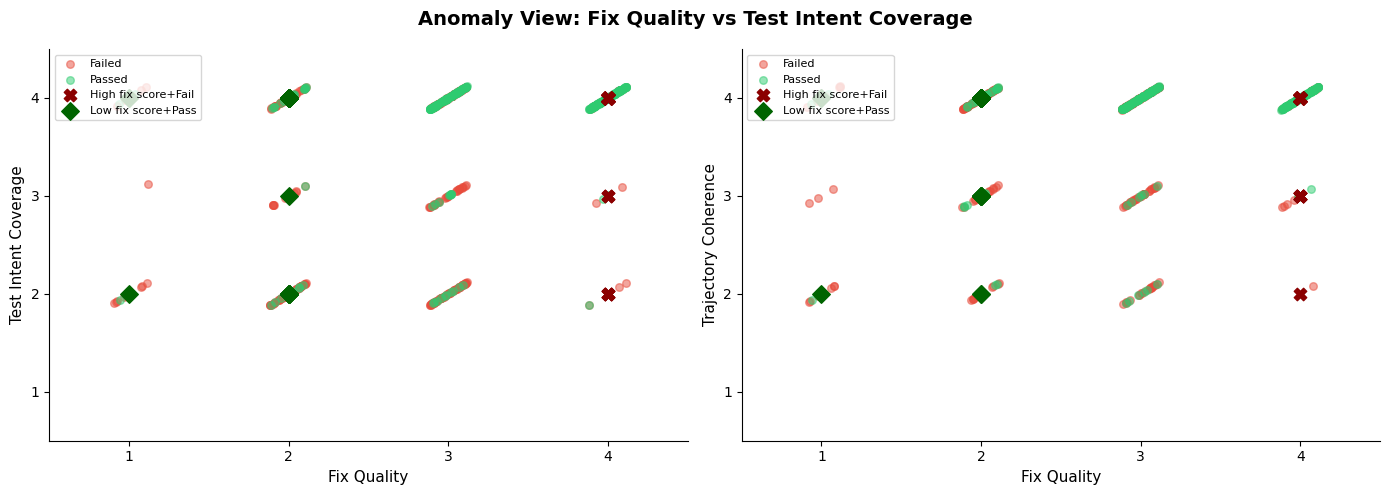

Saved: anomaly_scatter.png


In [18]:

# ── Anomaly cases: high score but failed / low score but passed ───────────────
from IPython.display import display, HTML

TARGET_DIMS = ["fix_quality", "test_intent_coverage"]
TARGET_LABELS = {
    "fix_quality": "Fix Quality",
    "test_intent_coverage": "Test Intent Coverage",
}

# Thresholds
HIGH_SCORE  = 4          # score >= HIGH_SCORE  AND resolved == False  → suspicious
LOW_SCORE   = 2          # score <= LOW_SCORE   AND resolved == True   → suspicious

# Work on the eval-only subset
df_w = df[df["resolved"].notna()].copy()

DISPLAY_COLS = ["instance_id", "fix_quality", "test_intent_coverage",
                "trajectory_coherence", "overall_score", "resolved"]

def style_df(sub_df, caption):
    """Render a styled table with a caption."""
    styled = (
        sub_df[DISPLAY_COLS]
        .sort_values("overall_score", ascending=False)
        .reset_index(drop=True)
        .style
        .set_caption(f"<b>{caption}</b>")
        .format({
            "fix_quality": "{:.0f}",
            "test_intent_coverage": "{:.0f}",
            "trajectory_coherence": "{:.0f}",
            "overall_score": "{:.2f}",
        })
        .set_table_styles([
            {"selector": "caption", "props": [("font-size", "14px"), ("text-align", "left"), ("padding-bottom", "6px")]},
            {"selector": "th", "props": [("background", "#3a3a3a"), ("color", "white"), ("padding", "6px 12px")]},
            {"selector": "td", "props": [("padding", "5px 12px")]},
            {"selector": "tr:nth-child(even)", "props": [("background", "#f5f5f5")]},
        ])
        .apply(lambda col: [
            "background-color: #ffd6d6" if not v else "" for v in sub_df["resolved"]
        ] if col.name == "resolved" else [""] * len(col), axis=0)
    )
    return styled

for dim in TARGET_DIMS:
    label = TARGET_LABELS[dim]
    
    # Anomaly 1: high score but FAILED (score >= HIGH_SCORE, resolved == False)
    high_fail = df_w[(df_w[dim] >= HIGH_SCORE) & (df_w["resolved"] == False)]
    
    # Anomaly 2: low score but PASSED (score <= LOW_SCORE, resolved == True)
    low_pass = df_w[(df_w[dim] <= LOW_SCORE) & (df_w["resolved"] == True)]

    print(f"\n{'='*70}")
    print(f"  Dimension: {label}")
    print(f"{'='*70}")
    print(f"  High score (≥{HIGH_SCORE}) but FAILED  → {len(high_fail)} instance(s)")
    print(f"  Low  score (≤{LOW_SCORE}) but PASSED   → {len(low_pass)} instance(s)")
    
    if len(high_fail):
        display(style_df(high_fail, f"[{label}] Score ≥ {HIGH_SCORE} but FAILED"))
    else:
        print(f"  No high-score failures found.")
    
    if len(low_pass):
        display(style_df(low_pass, f"[{label}] Score ≤ {LOW_SCORE} but PASSED"))
    else:
        print(f"  No low-score passes found.")

# ── Cross-dimension scatter: fix_quality vs test_intent_coverage, coloured by resolved ──
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Anomaly View: Fix Quality vs Test Intent Coverage", fontsize=14, fontweight="bold")

for ax, (dim_x, dim_y) in zip(axes,
        [("fix_quality", "test_intent_coverage"),
         ("fix_quality", "trajectory_coherence")]):

    passed = df_w[df_w["resolved"] == True]
    failed = df_w[df_w["resolved"] == False]

    # jitter to reveal overlapping points
    jitter = lambda s: s + np.random.default_rng(42).uniform(-0.12, 0.12, len(s))

    ax.scatter(jitter(failed[dim_x]), jitter(failed[dim_y]),
               c="#e74c3c", alpha=0.5, s=30, label="Failed", zorder=2)
    ax.scatter(jitter(passed[dim_x]), jitter(passed[dim_y]),
               c="#2ecc71", alpha=0.5, s=30, label="Passed", zorder=2)

    # Highlight anomalies
    hi_fail = df_w[(df_w[dim_x] >= HIGH_SCORE) & (df_w["resolved"] == False)]
    lo_pass = df_w[(df_w[dim_x] <= LOW_SCORE) & (df_w["resolved"] == True)]

    ax.scatter(hi_fail[dim_x], hi_fail[dim_y],
               c="darkred", s=80, marker="X", zorder=4, label=f"High {dim_x.split('_')[0]} score+Fail")
    ax.scatter(lo_pass[dim_x], lo_pass[dim_y],
               c="darkgreen", s=80, marker="D", zorder=4, label=f"Low {dim_x.split('_')[0]} score+Pass")

    ax.set_xlabel(TARGET_LABELS.get(dim_x, dim_x), fontsize=11)
    ax.set_ylabel(TARGET_LABELS.get(dim_y, dim_y.replace("_", " ").title()), fontsize=11)
    ax.set_xticks([1, 2, 3, 4]); ax.set_yticks([1, 2, 3, 4])
    ax.set_xlim(0.5, 4.5); ax.set_ylim(0.5, 4.5)
    ax.legend(fontsize=8, loc="upper left")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("anomaly_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: anomaly_scatter.png")


In [35]:
eval_records[0].keys()

dict_keys(['instance_id', 'test_result', 'instruction', 'metadata', 'history', 'metrics', 'error', 'instance'])

In [ ]:
eval_record = next(i for i in eval_records if i["instance_id"] == "conan-io__conan-13326")
print(eval_record['test_result']['test_output'])
print(eval_record['test_result']['test_result'])

+ source /opt/miniconda3/bin/activate
++ _CONDA_ROOT=/opt/miniconda3
++ . /opt/miniconda3/etc/profile.d/conda.sh
+++ export CONDA_EXE=/opt/miniconda3/bin/conda
+++ CONDA_EXE=/opt/miniconda3/bin/conda
+++ export _CE_M=
+++ _CE_M=
+++ export _CE_CONDA=
+++ _CE_CONDA=
+++ export CONDA_PYTHON_EXE=/opt/miniconda3/bin/python
+++ CONDA_PYTHON_EXE=/opt/miniconda3/bin/python
+++ '[' -z x ']'
++ conda activate
++ local cmd=activate
++ case "$cmd" in
++ __conda_activate activate
++ '[' -n '' ']'
++ local ask_conda
+++ PS1=
+++ __conda_exe shell.posix activate
+++ /opt/miniconda3/bin/conda shell.posix activate
++ ask_conda='. "/openhands/micromamba/envs/openhands/etc/conda/deactivate.d/libglib_deactivate.sh"
PS1='\''(base) '\''
export PATH='\''/opt/miniconda3/bin:/usr/bin:/bin:/usr/sbin:/sbin:/openhands/micromamba/bin:/openhands/bin:/usr/bin:/bin:/usr/sbin:/sbin:/usr/bin:/bin:/usr/sbin:/sbin:$PATH'\''
export CONDA_PREFIX='\''/opt/miniconda3'\''
export CONDA_SHLVL='\''2'\''
export CONDA_DEFAULT_ENV